In [1]:
import cv2
import torch
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


image_dir = "../../Data/JPEGImages"
mask_dir = "../../Data/SegmentationClass"



classes = {
    1: 1,    # aeroplane
    2: 2,    # bicycle
    3: 3,    # bird
    7: 4,    # car
    8: 5,    # cat
    12: 6,   # dog
    13: 7,   # horse
    15: 8,   # person
    6: 9,    # bus
    14: 10   # motorbike
}


class_names = {
    1: "aeroplane",
    2: "bicycle",
    3: "bird",
    4: "car",
    5: "cat",
    6: "dog",
    7: "horse",
    8: "person",
    9: "bus",
    10: "motorbike"
}


images = []
masks = []


for name in os.listdir(image_dir):

    if not name.endswith(".jpg"):
        continue

    mask_name = name.replace(".jpg", ".png")

    mask_path = os.path.join(
        mask_dir,
        mask_name
    )

    if not os.path.exists(mask_path):
        continue


    image = cv2.imread(
        os.path.join(image_dir, name)
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    mask = np.array(
        Image.open(mask_path)
    )

    mask = torch.tensor(mask)

    new_mask = torch.zeros_like(mask)


    for old_id, new_id in classes.items():

        new_mask[mask == old_id] = new_id


    images.append(
        torch.tensor(image)
    )

    masks.append(new_mask)


print("Number of images:", len(images))
print("Image shape:", images[0].shape)
print("Mask shape:", masks[0].shape)
print("Mask values:", torch.unique(masks[0]))

Number of images: 2913
Image shape: torch.Size([281, 500, 3])
Mask shape: torch.Size([281, 500])
Mask values: tensor([0, 1, 8], dtype=torch.uint8)


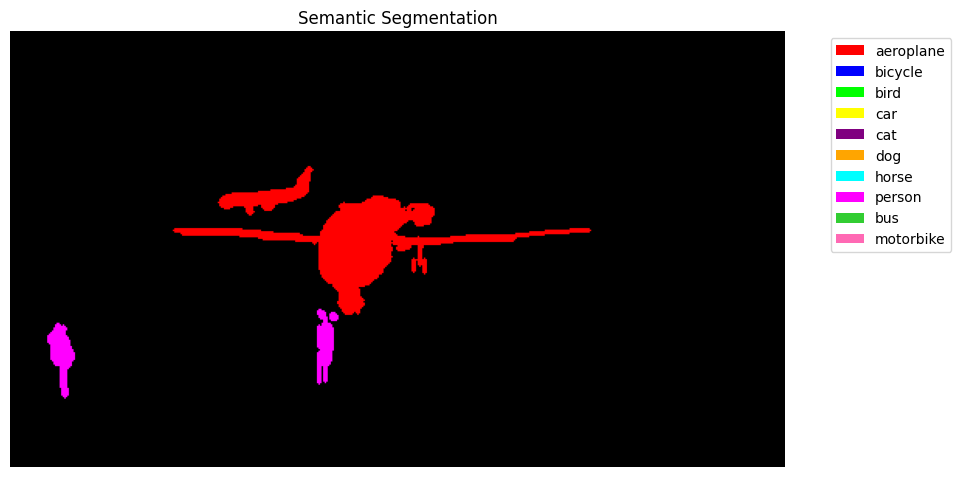

In [2]:
from matplotlib.patches import Patch
color_map = np.array([
    [0, 0, 0],          # 0 background
    [255, 0, 0],        # 1 aeroplane
    [0, 0, 255],        # 2 bicycle
    [0, 255, 0],        # 3 bird
    [255, 255, 0],      # 4 car
    [128, 0, 128],      # 5 cat
    [255, 165, 0],      # 6 dog
    [0, 255, 255],      # 7 horse
    [255, 0, 255],      # 8 person
    [50, 205, 50],      # 9 bus
    [255, 105, 180]     # 10 motorbike
])

index = 0

image = images[index]
mask = masks[index]


colored_mask = color_map[
    mask.numpy()
]

plt.figure(figsize=(10, 6))

plt.imshow(colored_mask)

plt.title("Semantic Segmentation")

plt.axis("off")


legend_elements = []


for class_id, name in class_names.items():

    color = color_map[class_id] / 255

    legend_elements.append(
        Patch(
            facecolor=color,
            label=name
        )
    )


plt.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()